# 가중치 초기화
기울기 소실 문제 해결을 위함

--> 가중치 감소(weight decay) 시키는 방향으로 문제 해결

```
0.01 * np.random.randn(10, 100)
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

In [ ]:
input_data = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

x = input_data

def get_activation(hidden_layer_size, x, w, a_func=sigmoid):
    for i in range(hidden_layer_size):
        if i != 0:
            x = activations[i - 1]

        a = np.dot(x, w)

        z = a_func(a)

        activations[i] = z
    return activations

In [ ]:
w = np.random.randn(node_num, node_num) * 1
z = sigmoid
activations = get_activation(hidden_layer_size, x, w, z)

In [ ]:
activations

{0: array([[9.99965881e-01, 9.99839578e-01, 1.10140657e-03, ...,
         9.99998441e-01, 9.10965846e-01, 9.96872398e-01],
        [1.00000000e+00, 9.99995327e-01, 3.82289842e-02, ...,
         1.89882985e-02, 1.18827419e-04, 9.99980807e-01],
        [9.98388339e-01, 2.69402691e-05, 9.97874200e-01, ...,
         9.07615861e-01, 9.99947496e-01, 1.72162884e-03],
        ...,
        [4.03914694e-04, 9.99984720e-01, 9.99999993e-01, ...,
         9.95546531e-01, 9.62763675e-07, 9.95685382e-01],
        [2.60486377e-01, 9.91467855e-01, 9.99999639e-01, ...,
         9.85707603e-01, 1.05418898e-02, 3.83930574e-07],
        [1.32073135e-01, 7.19147880e-01, 9.99835763e-01, ...,
         2.34707201e-04, 9.99999976e-01, 9.83388938e-01]]),
 1: array([[6.38456908e-01, 6.02843303e-01, 9.99701905e-01, ...,
         1.34879106e-01, 9.98961542e-01, 9.94023268e-01],
        [9.99823541e-01, 7.06894214e-04, 2.31744756e-02, ...,
         9.12281413e-01, 9.98304090e-01, 9.80312956e-01],
        [9.99178882

In [ ]:
def get_histogram(activations):
    for i, a in activations.items():
        plt.subplot(1, len(activations), i+1)
        plt.title(str(i+1) + "-layer")
        if i != 0: plt.yticks([], [])
        # plt.xlim(0.1, 1)
        # plt.ylim(0, 7000)
        plt.hist(a.flatten(), 30, range=(0,1))
    plt.show()

In [ ]:
len(activations)

5

In [ ]:
activations[0].shape

(1000, 100)

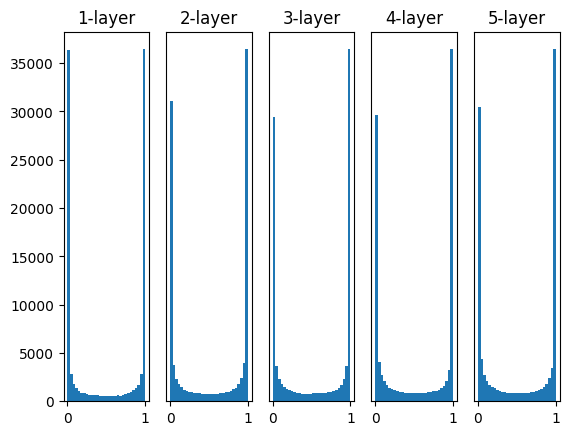

In [ ]:
get_histogram(activations)

Gradient vanishing : 기울기 소실

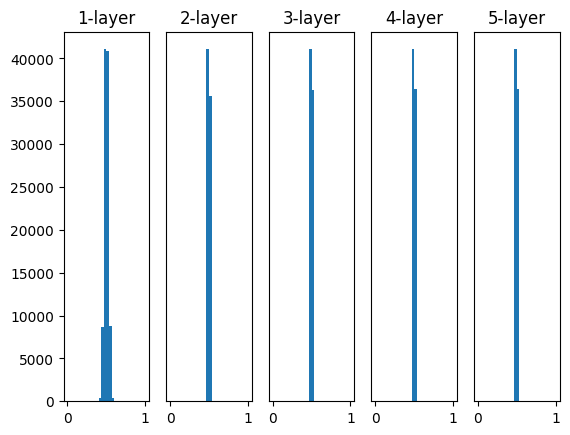

In [ ]:
w = np.random.randn(node_num, node_num) * 0.01
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

표현력 제한 문제

# Xavier 초기값 사용

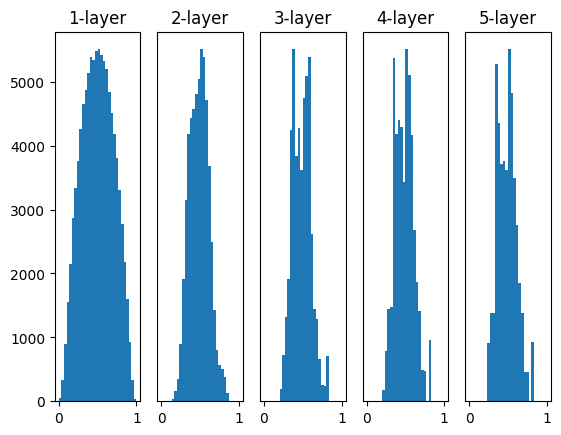

In [ ]:
w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

# He 초기값

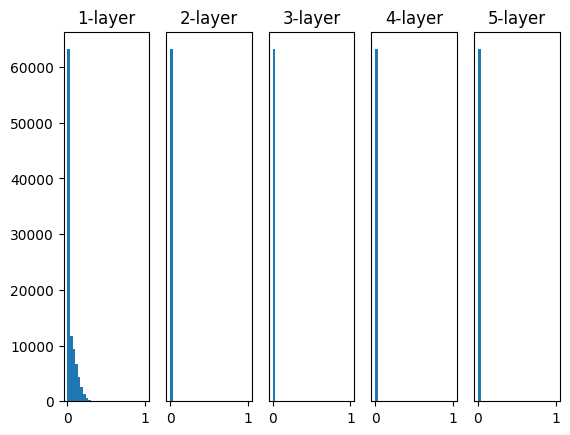

In [ ]:
w = np.random.randn(node_num, node_num) * 0.01
z = ReLU
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

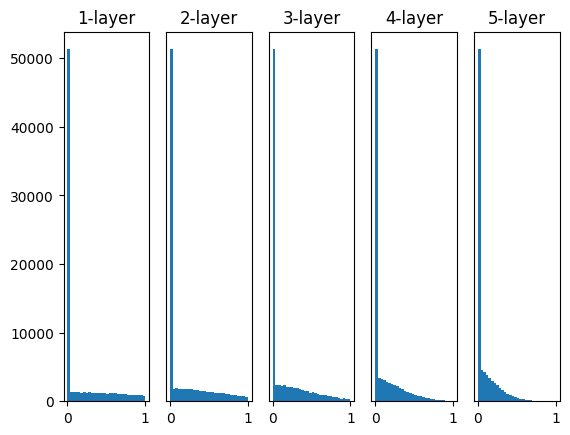

In [ ]:
w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

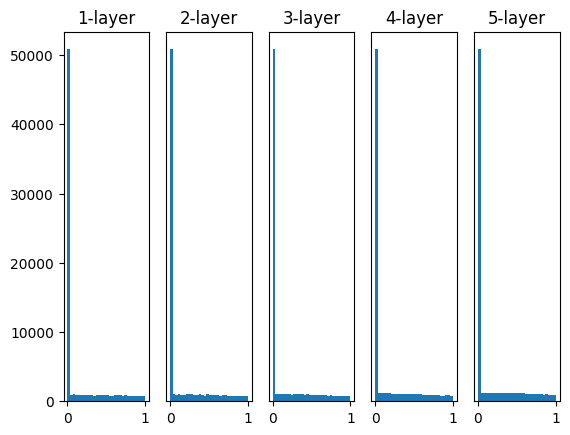

In [ ]:
w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

ReLU --> He 초기값

In [ ]:
from drive.MyDrive.data.mnistdata.mnist import load_mnist
from drive.MyDrive.data.util import smooth_curve
from drive.MyDrive.data.multi_layer_net import MultiLayerNet
from drive.MyDrive.data.optimizer import SGD

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [ ]:
train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

In [ ]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [ ]:
weight_init_types = {
    'std=0.01':0.01,
    'Xavier':'sigmoid',
    'He':'relu'
}
optimizer = SGD(lr = 0.01)

In [ ]:
networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []

-----iteration: 0-----
std=0.01 : 2.302523895040565
Xavier : 2.297796591274168
He : 2.35143423716515
-----iteration: 100-----
std=0.01 : 2.3025639422893134
Xavier : 2.2333244606839457
He : 1.3984508367357922
-----iteration: 200-----
std=0.01 : 2.299659576853876
Xavier : 2.058532879932164
He : 0.7352930182000585
-----iteration: 300-----
std=0.01 : 2.3008551309362195
Xavier : 1.4980963755232612
He : 0.41048434718335347
-----iteration: 400-----
std=0.01 : 2.297125841804176
Xavier : 0.994196400793462
He : 0.3921662537719336
-----iteration: 500-----
std=0.01 : 2.2973186125255314
Xavier : 0.7449866633930561
He : 0.36006387547725194
-----iteration: 600-----
std=0.01 : 2.303859021082305
Xavier : 0.6592763086866981
He : 0.3695398960310363
-----iteration: 700-----
std=0.01 : 2.306008555716301
Xavier : 0.5839073423518564
He : 0.32116138752426193
-----iteration: 800-----
std=0.01 : 2.303519402921393
Xavier : 0.4495567488762827
He : 0.31873853497736143
-----iteration: 900-----
std=0.01 : 2.30210185

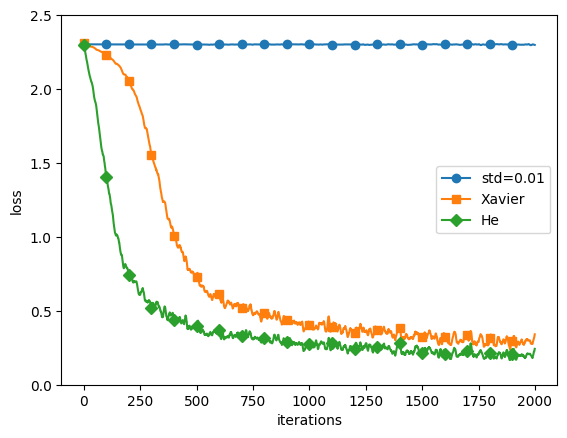

In [ ]:
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print('-----' + 'iteration: '+ str(i) + '-----')
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ' : ' + str(loss))

markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

# 배치 정규화

: 데이터 분포가 평균이 0, 분산이 1이 되도록 정규화

# Dropout

: 노드를 임의로 삭제하고 학습하는 방법

In [ ]:
from drive.MyDrive.data.multi_layer_net_extend import MultiLayerNetExtend
from drive.MyDrive.data.trainer import Trainer

In [ ]:
class Dropout:
    def __init__(self, dropout_ratio=0.15):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x*self.mask

        else:
            return x*(1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout*self.mask

In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [ ]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [ ]:
x_train = x_train[:300]
t_train = t_train[:300]

In [ ]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
t_train

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0,
       9, 1, 1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9,
       3, 9, 8, 5, 9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0, 4, 5,
       6, 1, 0, 0, 1, 7, 1, 6, 3, 0, 2, 1, 1, 7, 9, 0, 2, 6, 7, 8, 3, 9,
       0, 4, 6, 7, 4, 6, 8, 0, 7, 8, 3, 1, 5, 7, 1, 7, 1, 1, 6, 3, 0, 2,
       9, 3, 1, 1, 0, 4, 9, 2, 0, 0, 2, 0, 2, 7, 1, 8, 6, 4, 1, 6, 3, 4,
       5, 9, 1, 3, 3, 8, 5, 4, 7, 7, 4, 2, 8, 5, 8, 6, 7, 3, 4, 6, 1, 9,
       9, 6, 0, 3, 7, 2, 8, 2, 9, 4, 4, 6, 4, 9, 7, 0, 9, 2, 9, 5, 1, 5,
       9, 1, 2, 3, 2, 3, 5, 9, 1, 7, 6, 2, 8, 2, 2, 5, 0, 7, 4, 9, 7, 8,
       3, 2, 1, 1, 8, 3, 6, 1, 0, 3, 1, 0, 0, 1, 7, 2, 7, 3, 0, 4, 6, 5,
       2, 6, 4, 7, 1, 8, 9, 9, 3, 0, 7, 1, 0, 2, 0, 3, 5, 4, 6, 5, 8, 6,
       3, 7, 5, 8, 0, 9, 1, 0, 3, 1, 2, 2, 3, 3, 6, 4, 7, 5, 0, 6, 2, 7,
       9, 8, 5, 9, 2, 1, 1, 4, 4, 5, 6, 4, 1, 2, 5, 3, 9, 3, 9, 0, 5, 9,
       6, 5, 7, 4, 1, 3, 4, 0, 4, 8, 0, 4, 3, 6], d

In [ ]:
x_train.shape, t_train.shape

((300, 784), (300,))

In [ ]:
use_dropout=False
dropout_ratio=0.2

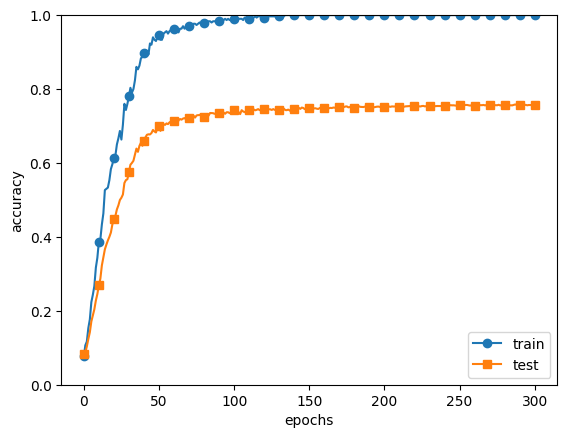

In [ ]:
network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=False)
trainer.train()
train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list
# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# True 일때 과적합이 확 줄었다.
use_dropout=True
dropout_ratio=0.2

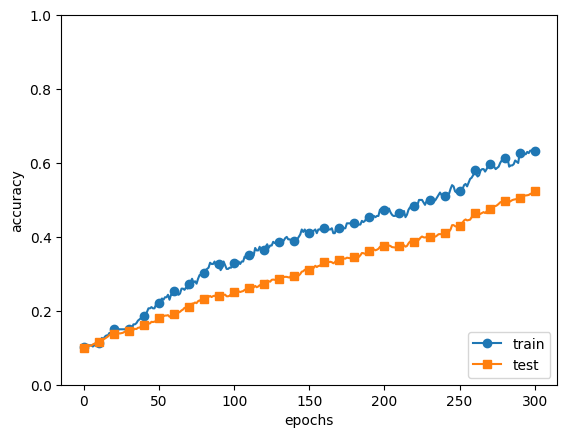

In [ ]:
network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=False)
trainer.train()
train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list
# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

# GPU 사용하기

In [ ]:
import tensorflow as tf
import timeit

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
!nvidia-smi

Tue May 12 05:39:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P0             25W /   70W |    1211MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

cpu 정보 알아보기

In [ ]:
!head -n 18 /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 85
model name	: Intel(R) Xeon(R) CPU @ 2.00GHz
stepping	: 3
microcode	: 0xffffffff
cpu MHz		: 2000.168
cache size	: 39424 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13


In [ ]:
!head /proc/meminfo

MemTotal:       13286940 kB
MemFree:         5153968 kB
MemAvailable:    9797100 kB
Buffers:          175292 kB
Cached:          4684564 kB
SwapCached:            0 kB
Active:           752864 kB
Inactive:        6907336 kB
Active(anon):       2432 kB
Inactive(anon):  2834520 kB


In [ ]:
with tf.device('/GPU:0'):
    a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
    b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

timeit 사용법

```python
timeit.timeit(stmt, setup, timer, number, globals)
stmt: 코드 문자열
setup: 코드 실행전에 미리 실행될 코드
timer: 시간 측정에 사용하는 함수. time.time
number: 실행 횟수
globals: 전역변수(딕셔너리)
```

In [ ]:
device_name = tf.test.gpu_device_name()

if device_name != '/device:GPU:0':
    print('Check device')
    raise SystemError('GPU device not found')

In [ ]:
device_name

'/device:GPU:0'

In [ ]:
def cpu():
    with tf.device('/cpu:0'):
        random_image_cpu = tf.random.normal((100, 100, 100, 3))
        net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)

In [ ]:
def gpu():
    with tf.device('/device:GPU:0'):
        random_image_gpu = tf.random.normal((100, 100, 100, 3))
        net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)

In [ ]:
cpu()

In [ ]:
gpu()

In [ ]:
cpu_time = timeit.timeit('cpu()', number=10, setup='from __main__ import cpu')
print(cpu_time)

5.256876566999836


In [ ]:
gpu_time = timeit.timeit('gpu()', number=10, setup='from __main__ import gpu')
print(gpu_time)

0.2639278420001574


30번 반복해서, cpu / gpu 사용시간 평균값 내보기

In [ ]:
a = []
for i in range(30):
    cpu_time = timeit.timeit('cpu()', number=10, setup='from __main__ import cpu')
    gpu_time = timeit.timeit('gpu()', number=10, setup='from __main__ import gpu')

    result = cpu_time / gpu_time
    a.append(result)
print(np.mean(a))

34.846320335174454


# 강사님 버전

30번 반복해서, cpu / gpu 사용시간 평균값 내보기

In [145]:
cpu_time_list = []
for i in range(30):
    cpu_time = timeit.timeit('cpu()', number=10, setup='from __main__ import cpu')
    cpu_time_list.append(cpu_time)
print(np.mean(cpu_time_list))

5.209840633400078


In [146]:
gpu_time_list = []
for i in range(30):
    gpu_time = timeit.timeit('gpu()', number=10, setup='from __main__ import gpu')
    gpu_time_list.append(gpu_time)
print(np.mean(gpu_time_list))

0.1003730132666836


In [147]:
np.mean(cpu_time_list) / np.mean(gpu_time_list)

np.float64(51.90479456423133)

In [148]:
import keras

In [150]:
def gpu_2():
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = keras.layers.Conv2D(32, 7)(random_image_gpu)

로컬에서 GPU 사용법

1. 그래픽카드, CUDA toolkit, cuDNN, python, tensorflow, 빌드도구 버전 맞추기(6박자)

2. 프로그램이 안돌아갈 때.
- gpu가 동작하는 환경에 설치된 라이브러리 목록 얻어내기

    pip freeze > requirements.txt

- requirements.txt 에 따라서 파이썬 버전 설치

- pip install -r requirements.txt : 에러가 난다.

- 텐서플로우 관련 라이브러리만 모아서 따로 설치
    
    tensorflow-io-gcs-filesystem, tensorflow

# 케라스

- 파이썬으로 지정된 오픈 소스 신경망 라이브러리.

- 텐서플로우 래퍼 라이브러리 (엔진: 텐서플로우)

In [154]:
from keras.layers import Dense, Activation
from keras.models import Sequential

In [157]:
model = Sequential()
model.add(Dense(64))
model.add(Activation('relu'))

In [158]:
model.add(Dense(64, activation='relu'))

In [160]:
model = Sequential()
model.add(Dense(50, activation='relu', input_dim=784))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [161]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,760 (155.31 KB)

 Trainable params: 39,760 (155.31 KB)

 Non-trainable params: 0 (0.00 B)

In [162]:
784*50+50

39250

    Dense : 완전 연결층, 입력층과 출력층이 모두 연결되어 있는 것을 의미

        - 첫번째 위치 인자 : 출력 노드 수
        
        - activation

        - linear : 디폴트 값으로 별도 활성화 함수 없이 입력 뉴런과 가중치의 계산 결과 그대로 출력.

        - sigmoid : 이진 분류 문제에서 출력층에 주로 사용되는 활성화 함수.

        - softmax : 셋 이상의 선택지 중 하나를 택하는 다중 클래스 분류 문제에서 출력층에 주로 사용되는 활성화 함수.

        - relu : 은닉층에 주로 사용되는 활성화 함수.
    
- input_dim : 자료의 특성 개수를 의미한다.

    예시) MNIST의 경우 : 28*28=784가 된다.

In [163]:
model = Sequential()

In [164]:
model.add(Dense(1, input_dim=3, activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [165]:
model = Sequential()
model.add(Dense(8, input_dim=4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

# compile()
: loss, optimizer, metrics 설정

In [167]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

- optimizer = 훈련 과정을 설정하는 옵티마이저를 설정합니다.
- loss = 훈련 과정에서 사용할 손실 함수(loss function)를 설정합니다.
- metrics = 훈련을 모니터링하기 위한 지표를 선택합니다.

sparse_categorical_crossentropy는 categorical_crossentropy와 동일하게 다중 클래스 분류에서 사용하지만, 레이블을 원-핫 인코딩 하지 않고 정수 인코딩 된 상태에서 수행 가능하다는 점이 다릅니다.

|문제유형|손실 함수명|출력층의 활성화 함수명|
|------|---|---|
|회귀 문제|mean_squared_error|-|
|다중 클래스 분류|categorical_crossentropy|소프트맥스|
|다중 클래스 분류|sparse_categorical_crossentropy|소프트맥스|
|이진 분류|binary_crossentropy|시그모이드|

binary cross entropy 함수

$$
L(t, y) = -\frac{1}{N} \sum_{i=1}^N[t_i log(y_i) + (1 - t_i)log(1 - y_i)]
$$

/tmp/ipykernel_887/4222480221.py:4: RuntimeWarning: invalid value encountered in log
  plt.plot(x, -np.log(x))


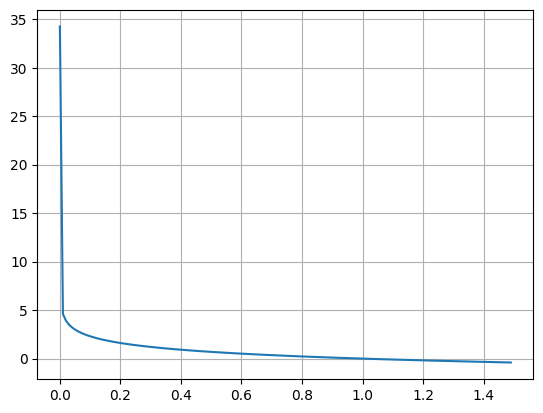

In [168]:
import numpy as np
import matplotlib.pyplot as plt
x = np.arange(-1.5, 1.5, 0.01)
plt.plot(x, -np.log(x))
plt.grid()

# fit : 훈련

- 모델 학습 : 모델이 오차로부터 매개변수를 업데이트 시키는 과정

- 학습, 훈련, 적합(fitting) 이라 부름

- 첫번째 인자 : 훈련 데이터

- 두번째 인자 : 지도 학습에서 레이블 데이터

- epochs

    1. 전체 데이터를 모두 사용한 것을 의미, 총 훈련 횟수를 정한다.
    
        총 훈련 횟수를 정한다.

- batch_size : 배치 크기, 기본값 32(None 가능)

In [171]:
# model.fit(X_train, y_trian, epochs=10, batch_size=32)

전체 데이터 개수가 2000개 이고, batch=500 --> 1 epoch = 4

epochs=10 이라 하면, 모델은 학습을 4 * 10 번 반복하게 된다.

In [178]:
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0, validation_data=(X_val, y_val))
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.2)

# 평가(Evaluation) 예측(Prediction)



In [179]:
# model.evaluate(X_test, y_test, batch_size=32) 이런식으로 작성

In [180]:
# model.predict(X_input, batch_size=32)

# 모델의 저장과 불러오기

In [181]:
model.save('model_name.keras') # model_name.h5 (hdf5)

save : 모델 저장

In [182]:
from tensorflow.keras.models import load_model

In [183]:
model = load_model('model_name.keras') # 저장 해둔 모델을 불러온다.

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# 예제

In [199]:
data = np.random.random((1000, 100))
labels = np.random.randint(2, size=(1000, 1))

In [201]:
data[:2]

array([[0.98672343, 0.51760832, 0.87956478, 0.88193009, 0.40447335,
        0.17041842, 0.6103686 , 0.11614607, 0.69316977, 0.88035302,
        0.63627164, 0.50180492, 0.36163616, 0.99623085, 0.52993822,
        0.16636562, 0.08884104, 0.49697617, 0.03838846, 0.03831807,
        0.00712149, 0.45312021, 0.90085783, 0.56382215, 0.11627617,
        0.4931904 , 0.19737018, 0.4547268 , 0.31344966, 0.83232174,
        0.89912585, 0.35180062, 0.8910656 , 0.1577338 , 0.02177046,
        0.52189791, 0.58004955, 0.09628077, 0.06719248, 0.58392815,
        0.12761183, 0.54502786, 0.0875808 , 0.71450492, 0.22679267,
        0.41726472, 0.57011938, 0.86747203, 0.7287138 , 0.60494458,
        0.03703393, 0.59240765, 0.55918022, 0.6902358 , 0.18204088,
        0.46499439, 0.44643203, 0.11670763, 0.89751299, 0.66538558,
        0.64560232, 0.17588031, 0.84048756, 0.28039936, 0.50133752,
        0.19039431, 0.51321953, 0.70603615, 0.31074626, 0.06168113,
        0.81457606, 0.13743034, 0.80728071, 0.87

In [200]:
labels[:2]

array([[1],
       [0]])

In [202]:
data.shape, labels.shape

((1000, 100), (1000, 1))

In [203]:
model = Sequential()

In [204]:
model.add(Dense(32, input_dim=100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [205]:
model.fit(data, labels, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5470 - loss: 0.7008
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5640 - loss: 0.6911
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5640 - loss: 0.6858
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5760 - loss: 0.6805
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5750 - loss: 0.6767
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5810 - loss: 0.6713
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5800 - loss: 0.6693
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6080 - loss: 0.6665
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6130 - loss: 0.6616
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6190 - loss: 0.6584


In [206]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,532 (25.52 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,267 (12.77 KB)